# Main Pipeline Benchmark Notebook

This notebook mirrors the active `main.py` experiment flow in a notebook format.

Pipeline:
1. Load data
2. Create sliding windows
3. Train all registered models from the current factory
4. Generate samples
5. Compute the same evaluation metrics
6. Plot and compare the models


In [9]:
import os
import sys
import time
import random
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from IPython.display import display

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / 'main.py').exists():
    sys.path.insert(0, str(PROJECT_ROOT))
else:
    PROJECT_ROOT = Path('/home/wan/psc/sbts_advanced')
    sys.path.insert(0, str(PROJECT_ROOT))

from data.loaders import load_etf_data, load_synthetic_data, create_sliding_windows
from models.factory import get_model, get_default_config, list_models
from metrics import discriminative_score_metrics, predictive_score_metrics
from metrics.numba_metrics import compute_all_metrics_numba, compute_stylized_facts_numba
from visualization import set_style

warnings.filterwarnings('ignore')
set_style()


## Configuration

By default this notebook runs all models currently registered in `models.factory`.
If the full run is too heavy, replace `MODELS_TO_RUN` with a smaller subset.


In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Choose the dataset used by the benchmark loop below.
# Options: 'merton', 'ou_standard', 'ou_high_frequency', 'stock'.
# 'google' is still accepted as a backward-compatible alias for 'stock'.
BENCHMARK_DATASET = 'stock'

# Used when BENCHMARK_DATASET is 'stock' or 'google'.
# Examples: 'GOOGL', 'SPY', 'QQQ'. Any single yfinance ticker should work.
STOCK_TICKER = 'QQQ'
PREPARE_SIMULATED_DATASETS = True
PLOT_DATASET_SAMPLES = True

MODELS_TO_RUN = list(list_models().keys())
# Example lighter subset:
# MODELS_TO_RUN = ['jd_sbts', 'jd_sbts_f', 'lightsb', 'timegan', 'diffusion_ts', 'rnn', 'transformer_ar']

DATASET_CONFIGS = {
    'merton': {
        'M': 1000,
        'N': 100,
        'dt': 1 / 252,
        'N_pi': 100,
        'Y0': 1.0,
        'a': 0.0,
        'b': 2.0,
        'lambda_eta': 10.0,
        'm_J': 0.0,
        'v_J': 0.8,
        'representation': 'path',  # 'path' -> (M, N + 1, 1); 'increments' -> (M, N, 1)
        'train_frac': 0.70,
        'val_frac': 0.15,
        'shuffle': True,
    },
    'ou_standard': {
        'M': 1000,
        'N': 100,
        'dt': 1 / 252,
        'theta': 100.0,
        'a': 1.0,
        'b': 10.0,
        'Y0': 1.0,
        'representation': 'path',
        'train_frac': 0.70,
        'val_frac': 0.15,
        'shuffle': True,
    },
    'ou_high_frequency': {
        'M': 1000,
        'N': 1000,
        'dt': (1 / 252) * (1 / 10),
        'theta': 100.0,
        'a': 1.0,
        'b': 10.0,
        'Y0': 1.0,
        'representation': 'path',
        'train_frac': 0.70,
        'val_frac': 0.15,
        'shuffle': True,
    },
    'stock': {
        'ticker': STOCK_TICKER,
        'start_date': '2004-01-01',
        'end_date': '2019-12-31',
        'features': ['High', 'Low', 'Open', 'Close', 'Adj Close', 'Volume'],
        'window_length': 24,
        'normalization': 'base_one',  # 'base_one', 'standard', or 'none'
        'train_frac': 0.70,
        'val_frac': 0.15,
        'shuffle': True,
    },
}

# Backward-compatible alias for older runs that used BENCHMARK_DATASET = 'google'.
DATASET_CONFIGS['google'] = DATASET_CONFIGS['stock'].copy()

TRAINING_OVERRIDES = {
    'seed': SEED,
    'verbose': False,
    'lstm_epochs': 25,
    'timegan_epochs': 20,
    'diffusion_epochs': 25,
    'lightsb_epochs': 25,
    'rnn_epochs': 25,
    'transformer_ar_epochs': 25,
    'n_generate': 64,
    'acf_max_lag': 15,
    'discriminative_iterations': 200,
    'predictive_iterations': 200,
}

FAIR_COMPARISON = {
    'enabled': True,
    'shared_eval_subset': True,
    'shared_conditioning': True,
    'reset_seed_per_model': True,
}

OUTPUT_DIR = PROJECT_ROOT / 'notebook_outputs' / 'benchmark_main_pipeline'
DATASET_OUTPUT_DIR = OUTPUT_DIR / 'datasets'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Models to run:', MODELS_TO_RUN)
print('Benchmark dataset:', BENCHMARK_DATASET)
print('Output dir:', OUTPUT_DIR)
print('Dataset output dir:', DATASET_OUTPUT_DIR)
print('Fair comparison settings:', FAIR_COMPARISON)


Models to run: ['jd_sbts', 'jd_sbts_f', 'jd_sbts_neural', 'jd_sbts_f_neural', 'lightsb', 'numba_sb', 'timegan', 'diffusion_ts', 'rnn', 'transformer_ar']
Benchmark dataset: ou_standard
Output dir: /home/wan/psc/sbts_advanced/notebook_outputs/benchmark_main_pipeline
Dataset output dir: /home/wan/psc/sbts_advanced/notebook_outputs/benchmark_main_pipeline/datasets
Fair comparison settings: {'enabled': True, 'shared_eval_subset': True, 'shared_conditioning': True, 'reset_seed_per_model': True}


## Paper Dataset Utilities

The simulators below follow the paper settings requested for the Merton jump-diffusion process, the standard and high-frequency OU processes, and the configurable yfinance stock/ETF dataset. Simulated paths use `N` as the number of observation intervals and return `N + 1` observations including `Y0`; increment windows therefore have length `N`.


In [11]:
def _json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer, np.floating, np.bool_)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, pd.Timestamp):
        return str(value)
    raise TypeError(f'Object of type {type(value).__name__} is not JSON serializable')


def compute_increments(paths):
    """Return first differences along the time axis."""
    return np.diff(np.asarray(paths), axis=1)


def create_train_val_test_splits(data, train_frac=0.70, val_frac=0.15, shuffle=True, seed=42):
    """Split an array on its first axis and keep the split indices for reproducibility."""
    if not 0 < train_frac < 1:
        raise ValueError('train_frac must be in (0, 1)')
    if not 0 <= val_frac < 1:
        raise ValueError('val_frac must be in [0, 1)')
    if train_frac + val_frac >= 1:
        raise ValueError('train_frac + val_frac must be less than 1')

    n_items = len(data)
    indices = np.arange(n_items)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    n_train = int(np.floor(train_frac * n_items))
    n_val = int(np.floor(val_frac * n_items))
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]

    return {
        'train': data[train_idx],
        'val': data[val_idx],
        'test': data[test_idx],
        'indices': {
            'train': train_idx,
            'val': val_idx,
            'test': test_idx,
        },
    }


def save_dataset_arrays(dataset_dir, raw_paths=None, increments=None, processed_windows=None, splits=None, metadata=None):
    """Save raw simulated paths, increments, processed windows, and split arrays."""
    dataset_dir = Path(dataset_dir)
    dataset_dir.mkdir(parents=True, exist_ok=True)

    if raw_paths is not None:
        np.save(dataset_dir / 'raw_paths.npy', raw_paths)
    if increments is not None:
        np.save(dataset_dir / 'increments.npy', increments)
    if processed_windows is not None:
        np.save(dataset_dir / 'processed_windows.npy', processed_windows)
    if splits is not None:
        for split_name in ['train', 'val', 'test']:
            np.save(dataset_dir / f'{split_name}_windows.npy', splits[split_name])
        np.savez_compressed(dataset_dir / 'split_indices.npz', **splits['indices'])
    if metadata is not None:
        with open(dataset_dir / 'metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2, default=_json_default)


def simulate_merton_jump_diffusion(
    M=1000,
    N=100,
    dt=1 / 252,
    N_pi=100,
    Y0=1.0,
    a=0.0,
    b=2.0,
    lambda_eta=10.0,
    m_J=0.0,
    v_J=0.8,
    seed=42,
):
    """
    Simulate 1D Merton jump-diffusion paths.

    Returns an array with shape (M, N + 1). The first column is Y0 and the
    remaining N columns are observations spaced by dt. Each dt interval is
    simulated using N_pi Euler substeps.

    Sign rule: jumps are sampled as negative magnitudes when the current state
    is above Y0 and positive magnitudes when it is below Y0. At exactly Y0, the
    sign is sampled symmetrically to avoid a deterministic bias.
    """
    rng = np.random.default_rng(seed)
    sub_dt = dt / N_pi
    sqrt_sub_dt = np.sqrt(sub_dt)

    paths = np.empty((M, N + 1), dtype=np.float64)
    paths[:, 0] = Y0
    y = np.full(M, Y0, dtype=np.float64)

    for obs_idx in range(1, N + 1):
        for _ in range(N_pi):
            dW = rng.standard_normal(M) * sqrt_sub_dt
            jump_counts = rng.poisson(lambda_eta * sub_dt, size=M)
            jump_update = np.zeros(M, dtype=np.float64)

            if jump_counts.any():
                max_jumps = int(jump_counts.max())
                raw_magnitudes = np.abs(rng.normal(m_J, v_J, size=(M, max_jumps)))
                active_jump = np.arange(max_jumps)[None, :] < jump_counts[:, None]
                random_sign = rng.choice(np.array([-1.0, 1.0]), size=M)
                jump_sign = np.where(y > Y0, -1.0, np.where(y < Y0, 1.0, random_sign))
                jump_update = (jump_sign[:, None] * raw_magnitudes * active_jump).sum(axis=1)

            y = y + a * sub_dt + b * dW + jump_update

        paths[:, obs_idx] = y

    return paths


def simulate_ou_process(M=1000, N=100, dt=1 / 252, theta=100.0, a=1.0, b=10.0, Y0=1.0, seed=42):
    """
    Euler-Maruyama simulator for dY_t = theta (a - Y_t) dt + b dW_t.

    Returns an array with shape (M, N + 1), including Y0 at index 0.
    """
    rng = np.random.default_rng(seed)
    paths = np.empty((M, N + 1), dtype=np.float64)
    paths[:, 0] = Y0

    for step in range(1, N + 1):
        prev = paths[:, step - 1]
        dW = rng.standard_normal(M) * np.sqrt(dt)
        paths[:, step] = prev + theta * (a - prev) * dt + b * dW

    return paths


def plot_sample_trajectories(paths, n=8, title='Sample trajectories', dt=None, feature=0):
    """Plot a few paths from a 2D path array or 3D window array."""
    arr = np.asarray(paths)
    if arr.ndim == 3:
        arr = arr[:, :, feature]
    if arr.ndim != 2:
        raise ValueError('paths must have shape (samples, steps) or (samples, steps, features)')

    n_plot = min(n, arr.shape[0])
    x_axis = np.arange(arr.shape[1]) if dt is None else np.arange(arr.shape[1]) * dt

    fig, ax = plt.subplots(figsize=(10, 4))
    for idx in range(n_plot):
        ax.plot(x_axis, arr[idx], linewidth=1.2, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Time' if dt is not None else 'Time step')
    ax.set_ylabel('Value')
    plt.tight_layout()
    plt.show()
    return ax


def compute_summary_statistics(paths):
    """Compute mean, std, increment std, and empirical quadratic variation."""
    arr = np.asarray(paths, dtype=np.float64)
    inc = compute_increments(arr)
    qv_by_path = np.sum(inc ** 2, axis=1)
    return {
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr, ddof=1)),
        'increment_std': float(np.std(inc, ddof=1)),
        'empirical_quadratic_variation': float(np.mean(qv_by_path)),
    }


def _time_grid_from_config(config, length, representation):
    dt = config.get('dt')
    if dt is None:
        return np.arange(length)
    if representation == 'increments':
        return np.arange(1, length + 1) * dt
    return np.arange(length) * dt


def _build_simulated_dataset(name, config, output_root, seed):
    dataset_dir = Path(output_root) / name
    representation = config.get('representation', 'path')

    if name == 'merton':
        paths = simulate_merton_jump_diffusion(
            M=config['M'],
            N=config['N'],
            dt=config['dt'],
            N_pi=config['N_pi'],
            Y0=config['Y0'],
            a=config['a'],
            b=config['b'],
            lambda_eta=config['lambda_eta'],
            m_J=config['m_J'],
            v_J=config['v_J'],
            seed=seed,
        )
        process = 'Merton jump-diffusion'
    elif name in {'ou_standard', 'ou_high_frequency'}:
        paths = simulate_ou_process(
            M=config['M'],
            N=config['N'],
            dt=config['dt'],
            theta=config['theta'],
            a=config['a'],
            b=config['b'],
            Y0=config['Y0'],
            seed=seed,
        )
        process = 'Ornstein-Uhlenbeck'
    else:
        raise ValueError(f'Unknown simulated dataset: {name}')

    increments = compute_increments(paths)
    path_windows = paths[:, :, None]
    increment_windows = increments[:, :, None]

    if representation == 'path':
        processed_windows = path_windows
    elif representation == 'increments':
        processed_windows = increment_windows
    else:
        raise ValueError("representation must be 'path' or 'increments'")

    splits = create_train_val_test_splits(
        processed_windows,
        train_frac=config.get('train_frac', 0.70),
        val_frac=config.get('val_frac', 0.15),
        shuffle=config.get('shuffle', True),
        seed=seed,
    )
    stats = compute_summary_statistics(paths)

    metadata = {
        'dataset': name,
        'process': process,
        'path_shape': paths.shape,
        'increments_shape': increments.shape,
        'processed_windows_shape': processed_windows.shape,
        'processed_windows_documentation': "shape is (num_windows, steps, features); features=1; path mode includes Y0 and has N+1 steps; increments mode has N steps",
        'representation': representation,
        'config': config,
        'summary_statistics': stats,
    }

    save_dataset_arrays(
        dataset_dir,
        raw_paths=paths,
        increments=increments,
        processed_windows=processed_windows,
        splits=splits,
        metadata=metadata,
    )
    pd.Series(stats, name='value').to_csv(dataset_dir / 'summary_statistics.csv')

    return {
        'name': name,
        'raw_data': path_windows,
        'raw_paths': paths,
        'increments': increments,
        'processed_windows': processed_windows,
        'splits': splits,
        'time_grid': _time_grid_from_config(config, processed_windows.shape[1], representation),
        'metadata': metadata,
        'dataset_dir': dataset_dir,
    }


def _normalize_stock_windows(windows, method='base_one', eps=1e-8):
    method = method.lower()
    windows = np.asarray(windows, dtype=np.float64)

    if method == 'none':
        return windows, {'method': 'none'}

    if method == 'base_one':
        first_values = windows[:, :1, :]
        safe_denominator = np.where(np.abs(first_values) > eps, first_values, 1.0)
        normalized = windows / safe_denominator
        return normalized, {
            'method': 'base_one',
            'zero_first_value_count': int(np.sum(np.abs(first_values) <= eps)),
        }

    if method == 'standard':
        mean = windows.mean(axis=1, keepdims=True)
        std = windows.std(axis=1, keepdims=True, ddof=0)
        zero_std_count = int(np.sum(std <= eps))
        safe_std = np.where(std > eps, std, 1.0)
        normalized = (windows - mean) / safe_std
        return normalized, {
            'method': 'standard',
            'zero_std_count': zero_std_count,
        }

    raise ValueError("normalization must be one of: 'base_one', 'standard', 'none'")


def download_stock_data(ticker='GOOGL', start_date='2004-01-01', end_date='2019-12-31', features=None, raw_csv_path=None):
    """Download configurable stock or ETF data with yfinance and keep the requested features."""
    try:
        import yfinance as yf
    except ImportError as exc:
        raise ImportError('yfinance is required for the stock dataset. Install it with: pip install yfinance') from exc

    features = features or ['High', 'Low', 'Open', 'Close', 'Adj Close', 'Volume']
    inclusive_end = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

    downloaded = yf.download(
        ticker,
        start=start_date,
        end=inclusive_end,
        progress=False,
        auto_adjust=False,
    )
    if downloaded.empty:
        raise ValueError(f'No data downloaded for {ticker} between {start_date} and {end_date}')

    if isinstance(downloaded.columns, pd.MultiIndex):
        if ticker in downloaded.columns.get_level_values(-1):
            downloaded = downloaded.xs(ticker, axis=1, level=-1)
        elif ticker in downloaded.columns.get_level_values(0):
            downloaded = downloaded.xs(ticker, axis=1, level=0)

    missing_cols = [col for col in features if col not in downloaded.columns]
    if missing_cols:
        raise ValueError(f'Missing expected columns for {ticker}: {missing_cols}')

    df = downloaded.loc[:, features].copy()
    df = df.sort_index()
    df = df.replace([np.inf, -np.inf], np.nan)
    rows_before = len(df)
    df = df.dropna(axis=0, how='any')
    dropped_rows = rows_before - len(df)

    if raw_csv_path is not None:
        raw_csv_path = Path(raw_csv_path)
        raw_csv_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(raw_csv_path)

    return df, {
        'ticker': ticker,
        'requested_start_date': start_date,
        'requested_end_date': end_date,
        'actual_start_date': str(df.index.min().date()),
        'actual_end_date': str(df.index.max().date()),
        'valid_rows': int(len(df)),
        'dropped_rows_missing_or_infinite': int(dropped_rows),
        'features': list(features),
    }


def create_stock_sliding_windows(frame, window_length=24):
    """Convert a full stock time series DataFrame to overlapping windows."""
    values = frame.to_numpy(dtype=np.float64)
    if len(values) < window_length:
        raise ValueError(f'Need at least {window_length} rows, got {len(values)}')
    return np.stack([values[start:start + window_length] for start in range(len(values) - window_length + 1)])


def _sanitize_ticker_for_path(ticker):
    safe = ''.join(ch if ch.isalnum() else '_' for ch in str(ticker).upper()).strip('_')
    return safe or 'TICKER'


def _build_stock_dataset(config, output_root, seed, dataset_name='stock'):
    ticker = str(config.get('ticker', 'GOOGL')).upper()
    safe_ticker = _sanitize_ticker_for_path(ticker)
    dataset_dir = Path(output_root) / f'{dataset_name}_{safe_ticker}'
    raw_csv_path = dataset_dir / f'{safe_ticker}_raw_daily.csv'
    df, download_report = download_stock_data(
        ticker=ticker,
        start_date=config.get('start_date', '2004-01-01'),
        end_date=config.get('end_date', '2019-12-31'),
        features=config.get('features'),
        raw_csv_path=raw_csv_path,
    )

    raw_windows = create_stock_sliding_windows(df, window_length=config.get('window_length', 24))
    processed_windows, normalization_report = _normalize_stock_windows(
        raw_windows,
        method=config.get('normalization', 'base_one'),
    )
    splits = create_train_val_test_splits(
        processed_windows,
        train_frac=config.get('train_frac', 0.70),
        val_frac=config.get('val_frac', 0.15),
        shuffle=config.get('shuffle', True),
        seed=seed,
    )

    metadata = {
        'dataset': dataset_name,
        'source': 'yfinance',
        'ticker': ticker,
        'output_shape_documentation': 'processed_windows shape is (num_windows, 24, 6) by default',
        'raw_csv_path': raw_csv_path,
        'raw_windows_shape': raw_windows.shape,
        'processed_windows_shape': processed_windows.shape,
        'download_report': download_report,
        'normalization_report': normalization_report,
        'config': config,
    }

    save_dataset_arrays(
        dataset_dir,
        raw_paths=None,
        increments=None,
        processed_windows=processed_windows,
        splits=splits,
        metadata=metadata,
    )
    np.save(dataset_dir / 'raw_windows.npy', raw_windows)

    print('Stock dataset report')
    print(f"- ticker: {download_report['ticker']}")
    print(f"- date range: {download_report['actual_start_date']} to {download_report['actual_end_date']}")
    print(f"- valid rows: {download_report['valid_rows']}")
    print(f"- windows: {processed_windows.shape[0]}")
    print(f"- features: {download_report['features']}")
    print(f"- normalization: {normalization_report['method']}")

    return {
        'name': dataset_name,
        'raw_data': df.to_numpy(dtype=np.float64)[None, :, :],
        'raw_frame': df,
        'raw_windows': raw_windows,
        'processed_windows': processed_windows,
        'splits': splits,
        'time_grid': np.arange(processed_windows.shape[1]),
        'metadata': metadata,
        'dataset_dir': dataset_dir,
    }


def build_benchmark_dataset(name, config, output_root, seed=42):
    """Build, save, and return one benchmark dataset bundle."""
    if name in {'merton', 'ou_standard', 'ou_high_frequency'}:
        return _build_simulated_dataset(name, config, output_root, seed)
    if name in {'stock', 'google'}:
        return _build_stock_dataset(config, output_root, seed, dataset_name=name)
    raise ValueError(f'Unknown BENCHMARK_DATASET: {name}')


## Prepare Benchmark Dataset

This cell builds the requested paper dataset, saves raw and processed arrays under `notebook_outputs/benchmark_main_pipeline/datasets`, and exposes train windows through `data` for the unchanged model benchmark loop.


Prepared merton: processed_windows=(1000, 101, 1), saved_to=/home/wan/psc/sbts_advanced/notebook_outputs/benchmark_main_pipeline/datasets/merton
Prepared ou_standard: processed_windows=(1000, 101, 1), saved_to=/home/wan/psc/sbts_advanced/notebook_outputs/benchmark_main_pipeline/datasets/ou_standard
Prepared ou_high_frequency: processed_windows=(1000, 1001, 1), saved_to=/home/wan/psc/sbts_advanced/notebook_outputs/benchmark_main_pipeline/datasets/ou_high_frequency
Selected dataset: ou_standard
Metadata: {'dataset': 'ou_standard', 'process': 'Ornstein-Uhlenbeck', 'path_shape': (1000, 101), 'increments_shape': (1000, 100), 'processed_windows_shape': (1000, 101, 1), 'processed_windows_documentation': 'shape is (num_windows, steps, features); features=1; path mode includes Y0 and has N+1 steps; increments mode has N steps', 'representation': 'path', 'config': {'M': 1000, 'N': 100, 'dt': 0.003968253968253968, 'theta': 100.0, 'a': 1.0, 'b': 10.0, 'Y0': 1.0, 'representation': 'path', 'train_fr

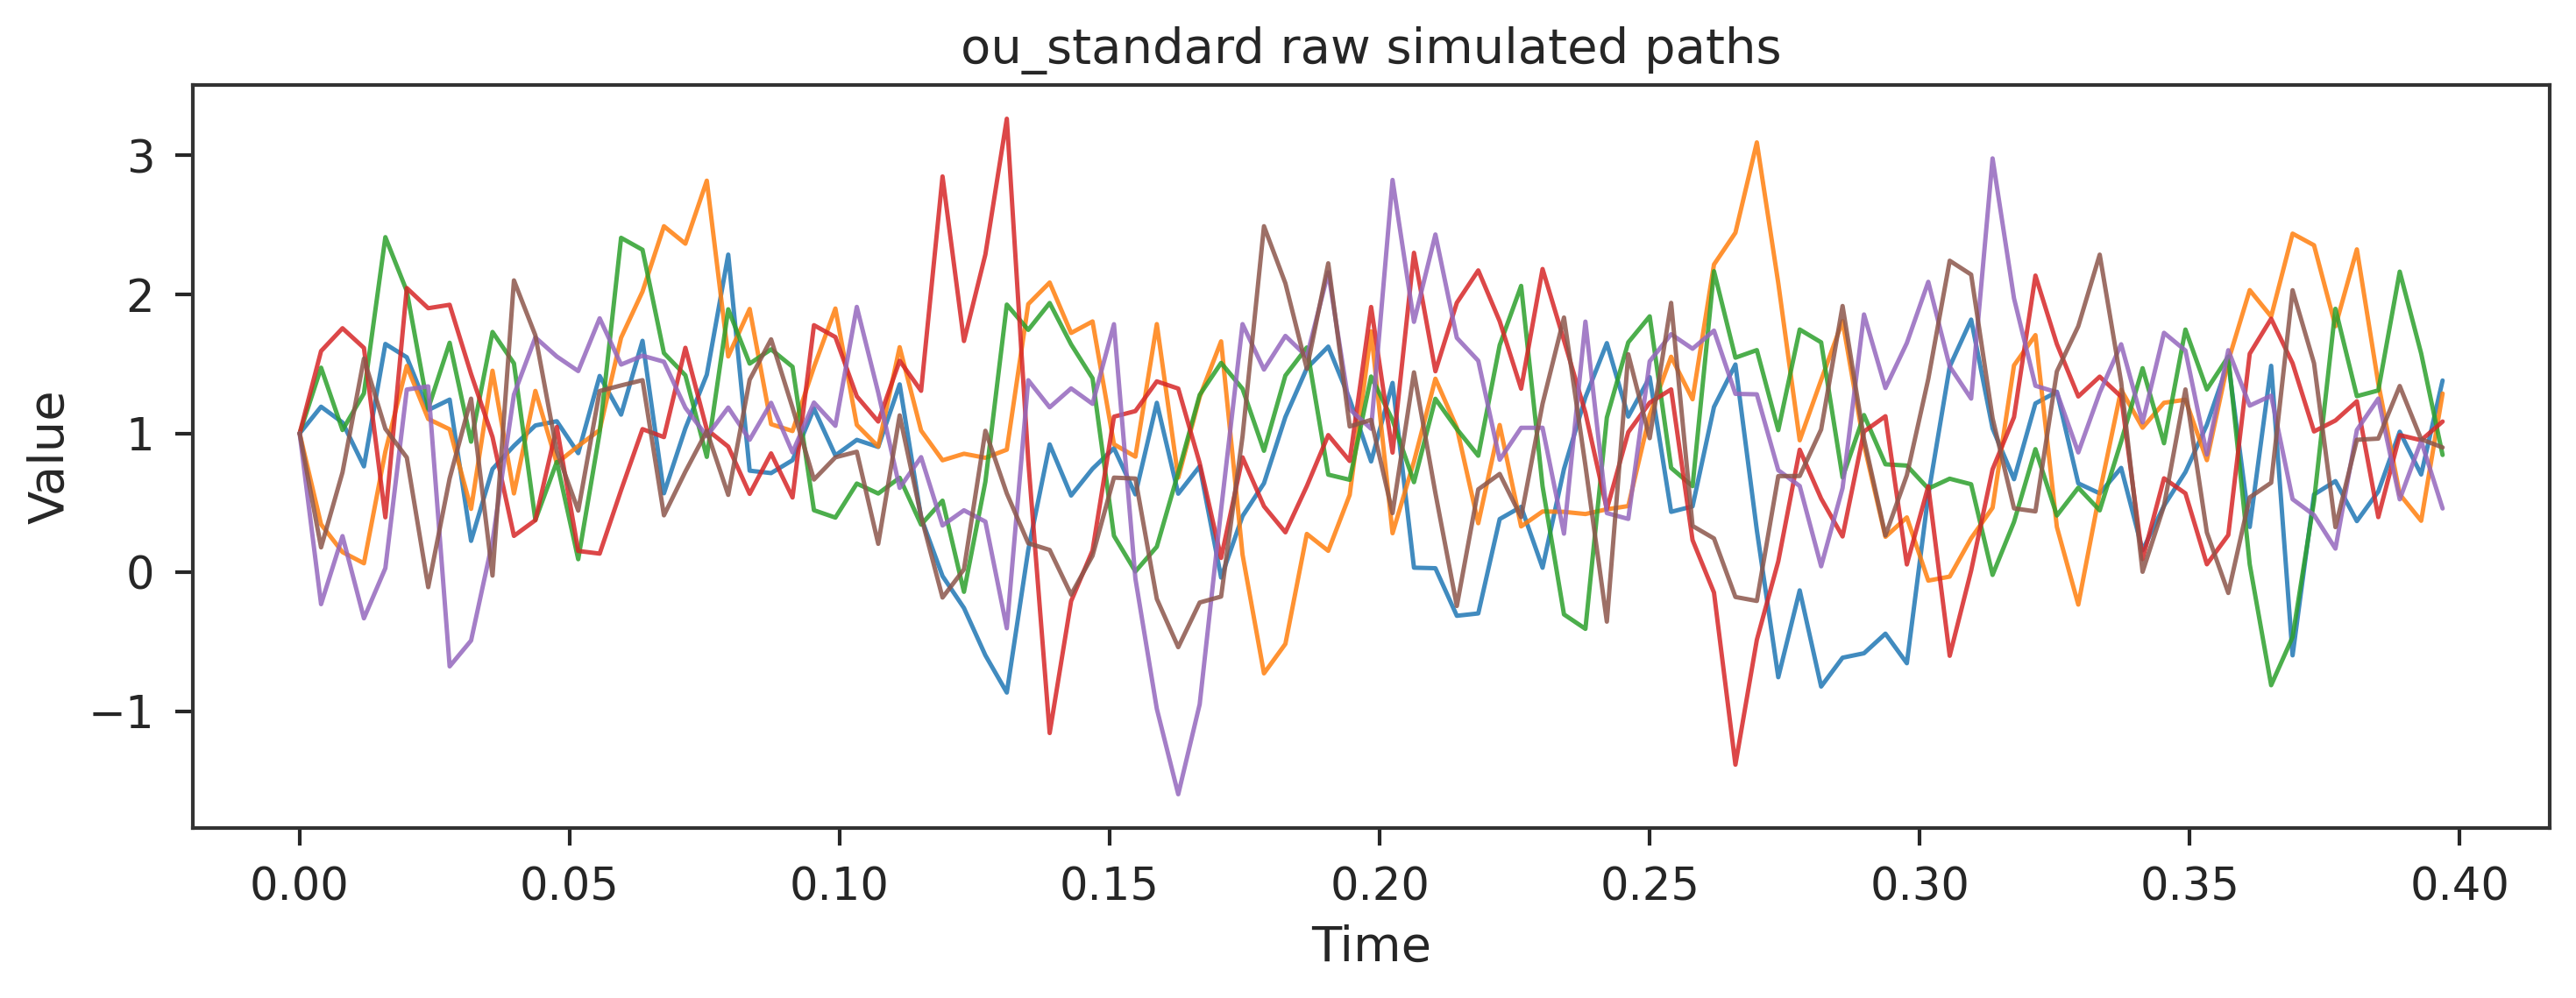

In [12]:
prepared_datasets = {}
if PREPARE_SIMULATED_DATASETS:
    for dataset_name in ['merton', 'ou_standard', 'ou_high_frequency']:
        prepared_datasets[dataset_name] = build_benchmark_dataset(
            dataset_name,
            DATASET_CONFIGS[dataset_name],
            DATASET_OUTPUT_DIR,
            seed=SEED,
        )
        print(
            f"Prepared {dataset_name}: "
            f"processed_windows={prepared_datasets[dataset_name]['processed_windows'].shape}, "
            f"saved_to={prepared_datasets[dataset_name]['dataset_dir']}"
        )

if BENCHMARK_DATASET in prepared_datasets:
    dataset_bundle = prepared_datasets[BENCHMARK_DATASET]
else:
    dataset_bundle = build_benchmark_dataset(
        BENCHMARK_DATASET,
        DATASET_CONFIGS[BENCHMARK_DATASET],
        DATASET_OUTPUT_DIR,
        seed=SEED,
    )

metadata = dataset_bundle['metadata']
raw_data = dataset_bundle['raw_data']
data_splits = dataset_bundle['splits']
data = data_splits['train'].astype(np.float32)
eval_pool = data_splits['test']
if len(eval_pool) == 0:
    eval_pool = data_splits['val']
if len(eval_pool) == 0:
    eval_pool = data

time_grid = np.asarray(dataset_bundle['time_grid'], dtype=np.float64)
if len(time_grid) != data.shape[1]:
    time_grid = np.linspace(0, 1, data.shape[1])

n_generate = min(TRAINING_OVERRIDES['n_generate'], len(eval_pool))
shared_eval_subset = eval_pool[:n_generate].astype(np.float32).copy()

print('Selected dataset:', BENCHMARK_DATASET)
print('Metadata:', metadata)
print('Raw data shape:', raw_data.shape)
print('Train window shape:', data.shape)
print('Validation window shape:', data_splits['val'].shape)
print('Test window shape:', data_splits['test'].shape)
print('Time grid length:', len(time_grid))
print('Samples for generation/evaluation:', n_generate)
print('Shared evaluation subset shape:', shared_eval_subset.shape)

if PLOT_DATASET_SAMPLES:
    if 'raw_paths' in dataset_bundle:
        plot_sample_trajectories(
            dataset_bundle['raw_paths'],
            n=6,
            title=f'{BENCHMARK_DATASET} raw simulated paths',
            dt=DATASET_CONFIGS[BENCHMARK_DATASET].get('dt'),
        )
    else:
        plot_sample_trajectories(
            dataset_bundle['processed_windows'][:6],
            n=6,
            title=f'{BENCHMARK_DATASET} processed windows, feature 0',
            feature=0,
        )


## Train, Generate, Evaluate

In [13]:
def extract_metric_value(result, key, default):
    if isinstance(result, dict):
        return float(result.get(key, default))
    if np.isscalar(result):
        return float(result)
    return float(default)


def reset_generation_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


CONDITIONED_X0_MODELS = {'jd_sbts', 'jd_sbts_f', 'jd_sbts_neural', 'jd_sbts_f_neural'}
CONDITIONED_PREFIX_MODELS = {'rnn', 'transformer_ar'}
WINDOW_LEVEL_NOISE_MODELS = {'lightsb'}
UNCONDITIONAL_MODELS = {'timegan', 'diffusion_ts'}


def build_generation_kwargs(model_name, model, reference_windows, n_samples, n_steps):
    kwargs = {'n_samples': n_samples, 'n_steps': n_steps}
    protocol = 'shared_seed_only'
    note = 'Unconditional generation; fairness comes from shared training data, shared eval subset, and reset RNG seed.'

    if model_name in WINDOW_LEVEL_NOISE_MODELS:
        protocol = 'shared_seed_only'
        note = 'Window-level bridge model; its x0 is flattened latent noise for the full window, not a real first-step state.'

    if FAIR_COMPARISON['enabled'] and FAIR_COMPARISON['shared_conditioning']:
        if model_name in CONDITIONED_X0_MODELS:
            kwargs['x0'] = reference_windows[:, 0, :].astype(np.float32)
            protocol = 'shared_x0'
            note = 'All samples use the same real initial states from the shared evaluation subset.'
        elif model_name in CONDITIONED_PREFIX_MODELS:
            context_len = int(getattr(model, 'context_len', max(1, n_steps // 2)))
            context_len = max(1, min(context_len, reference_windows.shape[1] - 1))
            kwargs['x0'] = reference_windows[:, :context_len, :].astype(np.float32)
            protocol = f'shared_prefix_len_{context_len}'
            note = f'All samples use the same real prefix windows of length {context_len} from the shared evaluation subset.'

    return kwargs, protocol, note


trained_models = {}
generated_data = {}
stress_trajectories = {}
metrics_results = {}
training_times = {}
generation_times = {}
generation_protocols = {}
fairness_notes = {}
failures = {}

for model_name in MODELS_TO_RUN:
    print()
    print(f'=== {model_name} ===')
    try:
        config = get_default_config(model_name)
        config.update(TRAINING_OVERRIDES)
        config.setdefault('transformer_ar_max_seq_len', data.shape[1])
        config.setdefault('window_size', data.shape[1])
        config.setdefault('n_steps', data.shape[1])

        model = get_model(model_name, config)

        start = time.perf_counter()
        model.fit(data, time_grid, verbose=False)
        training_times[model_name] = time.perf_counter() - start
        trained_models[model_name] = model

        if FAIR_COMPARISON['enabled'] and FAIR_COMPARISON['reset_seed_per_model']:
            reset_generation_seed(SEED)

        gen_kwargs, protocol, note = build_generation_kwargs(
            model_name,
            model,
            shared_eval_subset,
            n_generate,
            data.shape[1],
        )
        generation_protocols[model_name] = protocol
        fairness_notes[model_name] = note

        start = time.perf_counter()
        if hasattr(model, 'use_feedback') and model.use_feedback:
            gen_paths, stress = model.generate(return_stress=True, **gen_kwargs)
            stress_trajectories[model_name] = stress
        else:
            gen_paths = model.generate(**gen_kwargs)
        generation_times[model_name] = time.perf_counter() - start
        generated_data[model_name] = gen_paths

        real_eval = shared_eval_subset[:min(len(shared_eval_subset), len(gen_paths))]
        gen_eval = gen_paths[:len(real_eval)]

        stats = compute_all_metrics_numba(real_eval, gen_eval, max_acf_lag=TRAINING_OVERRIDES['acf_max_lag'])
        gen_returns = np.diff(gen_eval, axis=1)
        if gen_returns.ndim == 3:
            gen_returns_1d = gen_returns[:, :, 0]
        else:
            gen_returns_1d = gen_returns
        stylized = compute_stylized_facts_numba(gen_returns_1d.flatten())

        disc = discriminative_score_metrics(
            real_eval,
            gen_eval,
            iterations=TRAINING_OVERRIDES['discriminative_iterations'],
        )
        pred = predictive_score_metrics(
            real_eval,
            gen_eval,
            iterations=TRAINING_OVERRIDES['predictive_iterations'],
        )

        metrics_results[model_name] = {
            'train_time': training_times[model_name],
            'gen_time': generation_times[model_name],
            'generation_protocol': protocol,
            'wasserstein_distance': stats.get('wasserstein_distance', np.nan),
            'acf_mse': stats.get('acf_mse', np.nan),
            'correlation_distance': stats.get('correlation_distance', np.nan),
            'discriminative_score': extract_metric_value(disc, 'discriminative_score', np.nan),
            'predictive_score': extract_metric_value(pred, 'predictive_score', np.nan),
            **{f'stylized_{k}': v for k, v in stylized.items()},
        }

        print(
            f"train_time={training_times[model_name]:.2f}s, "
            f"gen_time={generation_times[model_name]:.2f}s, "
            f"shape={gen_paths.shape}, protocol={protocol}"
        )
    except Exception as exc:
        failures[model_name] = str(exc)
        print(f'FAILED: {exc}')



=== jd_sbts ===
train_time=36.73s, gen_time=0.09s, shape=(64, 101, 1), protocol=shared_x0

=== jd_sbts_f ===
train_time=35.72s, gen_time=0.09s, shape=(64, 101, 1), protocol=shared_x0

=== jd_sbts_neural ===
  [Neural Jump] Epoch 10/30, Loss: 0.0008
  [Neural Jump] Epoch 20/30, Loss: 0.0007
  [Neural Jump] Epoch 30/30, Loss: 0.0006
train_time=87.68s, gen_time=0.16s, shape=(64, 101, 1), protocol=shared_x0

=== jd_sbts_f_neural ===
  [Neural Jump] Epoch 10/30, Loss: 0.0008
  [Neural Jump] Epoch 20/30, Loss: 0.0007
  [Neural Jump] Epoch 30/30, Loss: 0.0006
train_time=88.27s, gen_time=0.15s, shape=(64, 101, 1), protocol=shared_x0

=== lightsb ===
train_time=0.43s, gen_time=0.05s, shape=(64, 101, 1), protocol=shared_seed_only

=== numba_sb ===
train_time=0.00s, gen_time=0.00s, shape=(64, 101, 1), protocol=shared_seed_only

=== timegan ===
train_time=2.16s, gen_time=0.00s, shape=(64, 101, 1), protocol=shared_seed_only

=== diffusion_ts ===
train_time=0.92s, gen_time=0.13s, shape=(64, 101, 1)

## Metrics Summary

In [14]:
df_metrics = pd.DataFrame(metrics_results).T.sort_index()
display(df_metrics)

if generation_protocols:
    protocol_df = pd.DataFrame({
        'generation_protocol': pd.Series(generation_protocols),
        'fairness_note': pd.Series(fairness_notes),
    }).sort_index()
    print('Generation protocol summary')
    display(protocol_df)

if failures:
    print('Failures:')
    display(pd.Series(failures, name='error'))


,train_time,gen_time,generation_protocol,wasserstein_distance,acf_mse,correlation_distance,discriminative_score,predictive_score,stylized_volatility_clustering,stylized_fat_tails,stylized_leverage_effect
diffusion_ts,0.920498,0.129681,shared_seed_only,0.288569,0.0069,0.0,0.115385,0.570319,0.023304,-0.033039,0.003186
jd_sbts,36.733765,0.093511,shared_x0,0.317969,0.003108,0.0,0.5,0.895484,-0.001274,0.039479,-0.003432
jd_sbts_f,35.723806,0.088909,shared_x0,0.332305,0.003098,0.0,0.5,0.887355,-0.001451,0.04027,-0.003719
jd_sbts_f_neural,88.271809,0.153916,shared_x0,0.046222,0.000227,0.0,0.038462,0.49906,0.01613,0.797795,0.002897
jd_sbts_neural,87.676114,0.155864,shared_x0,0.040578,0.000221,0.0,0.038462,0.499281,0.003089,0.764545,0.002958
lightsb,0.431295,0.048337,shared_seed_only,0.399893,0.006888,0.0,0.115385,0.568908,0.025158,0.04617,-0.000681
numba_sb,0.000569,0.000897,shared_seed_only,2.596094,0.008363,0.0,0.461538,0.526521,0.120838,0.518904,-0.002883
rnn,0.630095,0.023036,shared_prefix_len_50,0.282918,0.000071,0.0,0.192308,0.546354,0.386396,3.017953,-0.003391
timegan,2.160818,0.001371,shared_seed_only,0.563282,0.002934,0.0,0.5,1.155755,-0.003533,94.653908,-0.00119


Generation protocol summary


,generation_protocol,fairness_note
diffusion_ts,shared_seed_only,Unconditional generation; fairness comes from ...
jd_sbts,shared_x0,All samples use the same real initial states f...
jd_sbts_f,shared_x0,All samples use the same real initial states f...
jd_sbts_f_neural,shared_x0,All samples use the same real initial states f...
jd_sbts_neural,shared_x0,All samples use the same real initial states f...
lightsb,shared_seed_only,Window-level bridge model; its x0 is flattened...
numba_sb,shared_seed_only,Unconditional generation; fairness comes from ...
rnn,shared_prefix_len_50,All samples use the same real prefix windows o...
timegan,shared_seed_only,Unconditional generation; fairness comes from ...


Failures:


transformer_ar    transformer_ar_max_seq_len must be at least se...
Name: error, dtype: object

## Ranking And Decision Support


In [15]:
MAIN_METRICS = ['wasserstein_distance', 'acf_mse', 'predictive_score']
SECONDARY_METRICS = ['correlation_distance', 'discriminative_score']
MAIN_WEIGHT = 0.7
SECONDARY_WEIGHT = 0.3

comparison_df = df_metrics.copy()
real_subset = shared_eval_subset.copy()
real_returns = np.diff(real_subset, axis=1)
if real_returns.ndim == 3:
    real_returns_1d = real_returns[:, :, 0]
else:
    real_returns_1d = real_returns
real_stylized = compute_stylized_facts_numba(real_returns_1d.flatten())

stylized_delta_cols = []
for fact_name, real_value in real_stylized.items():
    metric_col = f'stylized_{fact_name}'
    if metric_col in comparison_df.columns:
        delta_col = f'{metric_col}_delta'
        scale = max(abs(real_value), 1e-8)
        comparison_df[delta_col] = (comparison_df[metric_col] - real_value).abs() / scale
        stylized_delta_cols.append(delta_col)

if stylized_delta_cols:
    comparison_df['stylized_score'] = comparison_df[stylized_delta_cols].mean(axis=1)
else:
    comparison_df['stylized_score'] = np.nan

main_available = [col for col in MAIN_METRICS if col in comparison_df.columns]
secondary_available = [col for col in SECONDARY_METRICS if col in comparison_df.columns]
if comparison_df['stylized_score'].notna().any():
    secondary_available = secondary_available + ['stylized_score']

main_ranks = comparison_df[main_available].rank(method='min', ascending=True)
secondary_ranks = comparison_df[secondary_available].rank(method='min', ascending=True)

comparison_df['main_rank_mean'] = main_ranks.mean(axis=1)
comparison_df['secondary_rank_mean'] = secondary_ranks.mean(axis=1)
comparison_df['overall_rank_score'] = (
    MAIN_WEIGHT * comparison_df['main_rank_mean']
    + SECONDARY_WEIGHT * comparison_df['secondary_rank_mean']
)

rank_columns = [
    'generation_protocol',
    'main_rank_mean',
    'secondary_rank_mean',
    'overall_rank_score',
    *main_available,
    *secondary_available,
]
ranking_summary = comparison_df[rank_columns].sort_values(
    ['overall_rank_score', 'main_rank_mean', 'secondary_rank_mean']
)

print('Fair-comparison note')
print('- All models use the same training windows and the same shared evaluation subset.')
print('- Conditioned models receive shared initial conditions or shared prefixes where their API supports it.')
print('- Unconditional models only share the reset RNG seed and the shared evaluation subset.')

print('Main metrics: lower is better')
display(comparison_df[main_available].sort_values(main_available).head(len(comparison_df)))

print('Secondary metrics: lower is better')
display(comparison_df[secondary_available].sort_values(secondary_available).head(len(comparison_df)))

print('Real stylized-facts reference')
display(pd.Series(real_stylized, name='real_value').to_frame())

if stylized_delta_cols:
    print('Stylized-facts relative error: lower is better')
    display(comparison_df[stylized_delta_cols + ['stylized_score']].sort_values('stylized_score'))

print('Overall ranking summary')
display(ranking_summary)


Fair-comparison note
- All models use the same training windows and the same shared evaluation subset.
- Conditioned models receive shared initial conditions or shared prefixes where their API supports it.
- Unconditional models only share the reset RNG seed and the shared evaluation subset.
Main metrics: lower is better


,wasserstein_distance,acf_mse,predictive_score
jd_sbts_neural,0.040578,0.000221,0.499281
jd_sbts_f_neural,0.046222,0.000227,0.49906
rnn,0.282918,0.000071,0.546354
diffusion_ts,0.288569,0.0069,0.570319
jd_sbts,0.317969,0.003108,0.895484
jd_sbts_f,0.332305,0.003098,0.887355
lightsb,0.399893,0.006888,0.568908
timegan,0.563282,0.002934,1.155755
numba_sb,2.596094,0.008363,0.526521


Secondary metrics: lower is better


,correlation_distance,discriminative_score,stylized_score
jd_sbts_neural,0.0,0.038462,14.152509
jd_sbts_f_neural,0.0,0.038462,15.125775
lightsb,0.0,0.115385,1.979816
diffusion_ts,0.0,0.115385,2.022562
rnn,0.0,0.192308,76.973375
numba_sb,0.0,0.461538,16.234375
jd_sbts,0.0,0.5,1.663718
jd_sbts_f,0.0,0.5,1.732121
timegan,0.0,0.5,1758.197853


Real stylized-facts reference


,real_value
volatility_clustering,0.006208
fat_tails,0.017952
leverage_effect,0.002163


Stylized-facts relative error: lower is better


,stylized_volatility_clustering_delta,stylized_fat_tails_delta,stylized_leverage_effect_delta,stylized_score
jd_sbts,1.205205,1.199071,2.586878,1.663718
jd_sbts_f,1.233677,1.243153,2.719533,1.732121
lightsb,3.052688,1.571789,1.314971,1.979816
diffusion_ts,2.753971,2.840378,0.473338,2.022562
jd_sbts_neural,0.502384,41.587167,0.367976,14.152509
jd_sbts_f_neural,1.598339,43.439326,0.339661,15.125775
numba_sb,18.465578,27.904343,2.333205,16.234375
rnn,61.243852,167.108001,2.568271,76.973375
timegan,1.569099,5271.474319,1.55014,1758.197853


Overall ranking summary


,generation_protocol,main_rank_mean,secondary_rank_mean,overall_rank_score,wasserstein_distance,acf_mse,predictive_score,correlation_distance,discriminative_score,stylized_score
jd_sbts_neural,shared_x0,1.666667,2.333333,1.866667,0.040578,0.000221,0.499281,0.0,0.038462,14.152509
jd_sbts_f_neural,shared_x0,2.000000,2.666667,2.200000,0.046222,0.000227,0.49906,0.0,0.038462,15.125775
rnn,shared_prefix_len_50,2.666667,4.666667,3.266667,0.282918,0.000071,0.546354,0.0,0.192308,76.973375
diffusion_ts,shared_seed_only,6.000000,2.666667,5.000000,0.288569,0.0069,0.570319,0.0,0.115385,2.022562
lightsb,shared_seed_only,6.333333,2.333333,5.133333,0.399893,0.006888,0.568908,0.0,0.115385,1.979816
jd_sbts_f,shared_x0,6.000000,3.333333,5.200000,0.332305,0.003098,0.887355,0.0,0.5,1.732121
jd_sbts,shared_x0,6.333333,3.000000,5.333333,0.317969,0.003108,0.895484,0.0,0.5,1.663718
numba_sb,shared_seed_only,7.000000,4.666667,6.300000,2.596094,0.008363,0.526521,0.0,0.461538,16.234375
timegan,shared_seed_only,7.000000,5.666667,6.600000,0.563282,0.002934,1.155755,0.0,0.5,1758.197853


## Main Metrics, Secondary Metrics, And Sanity Checks


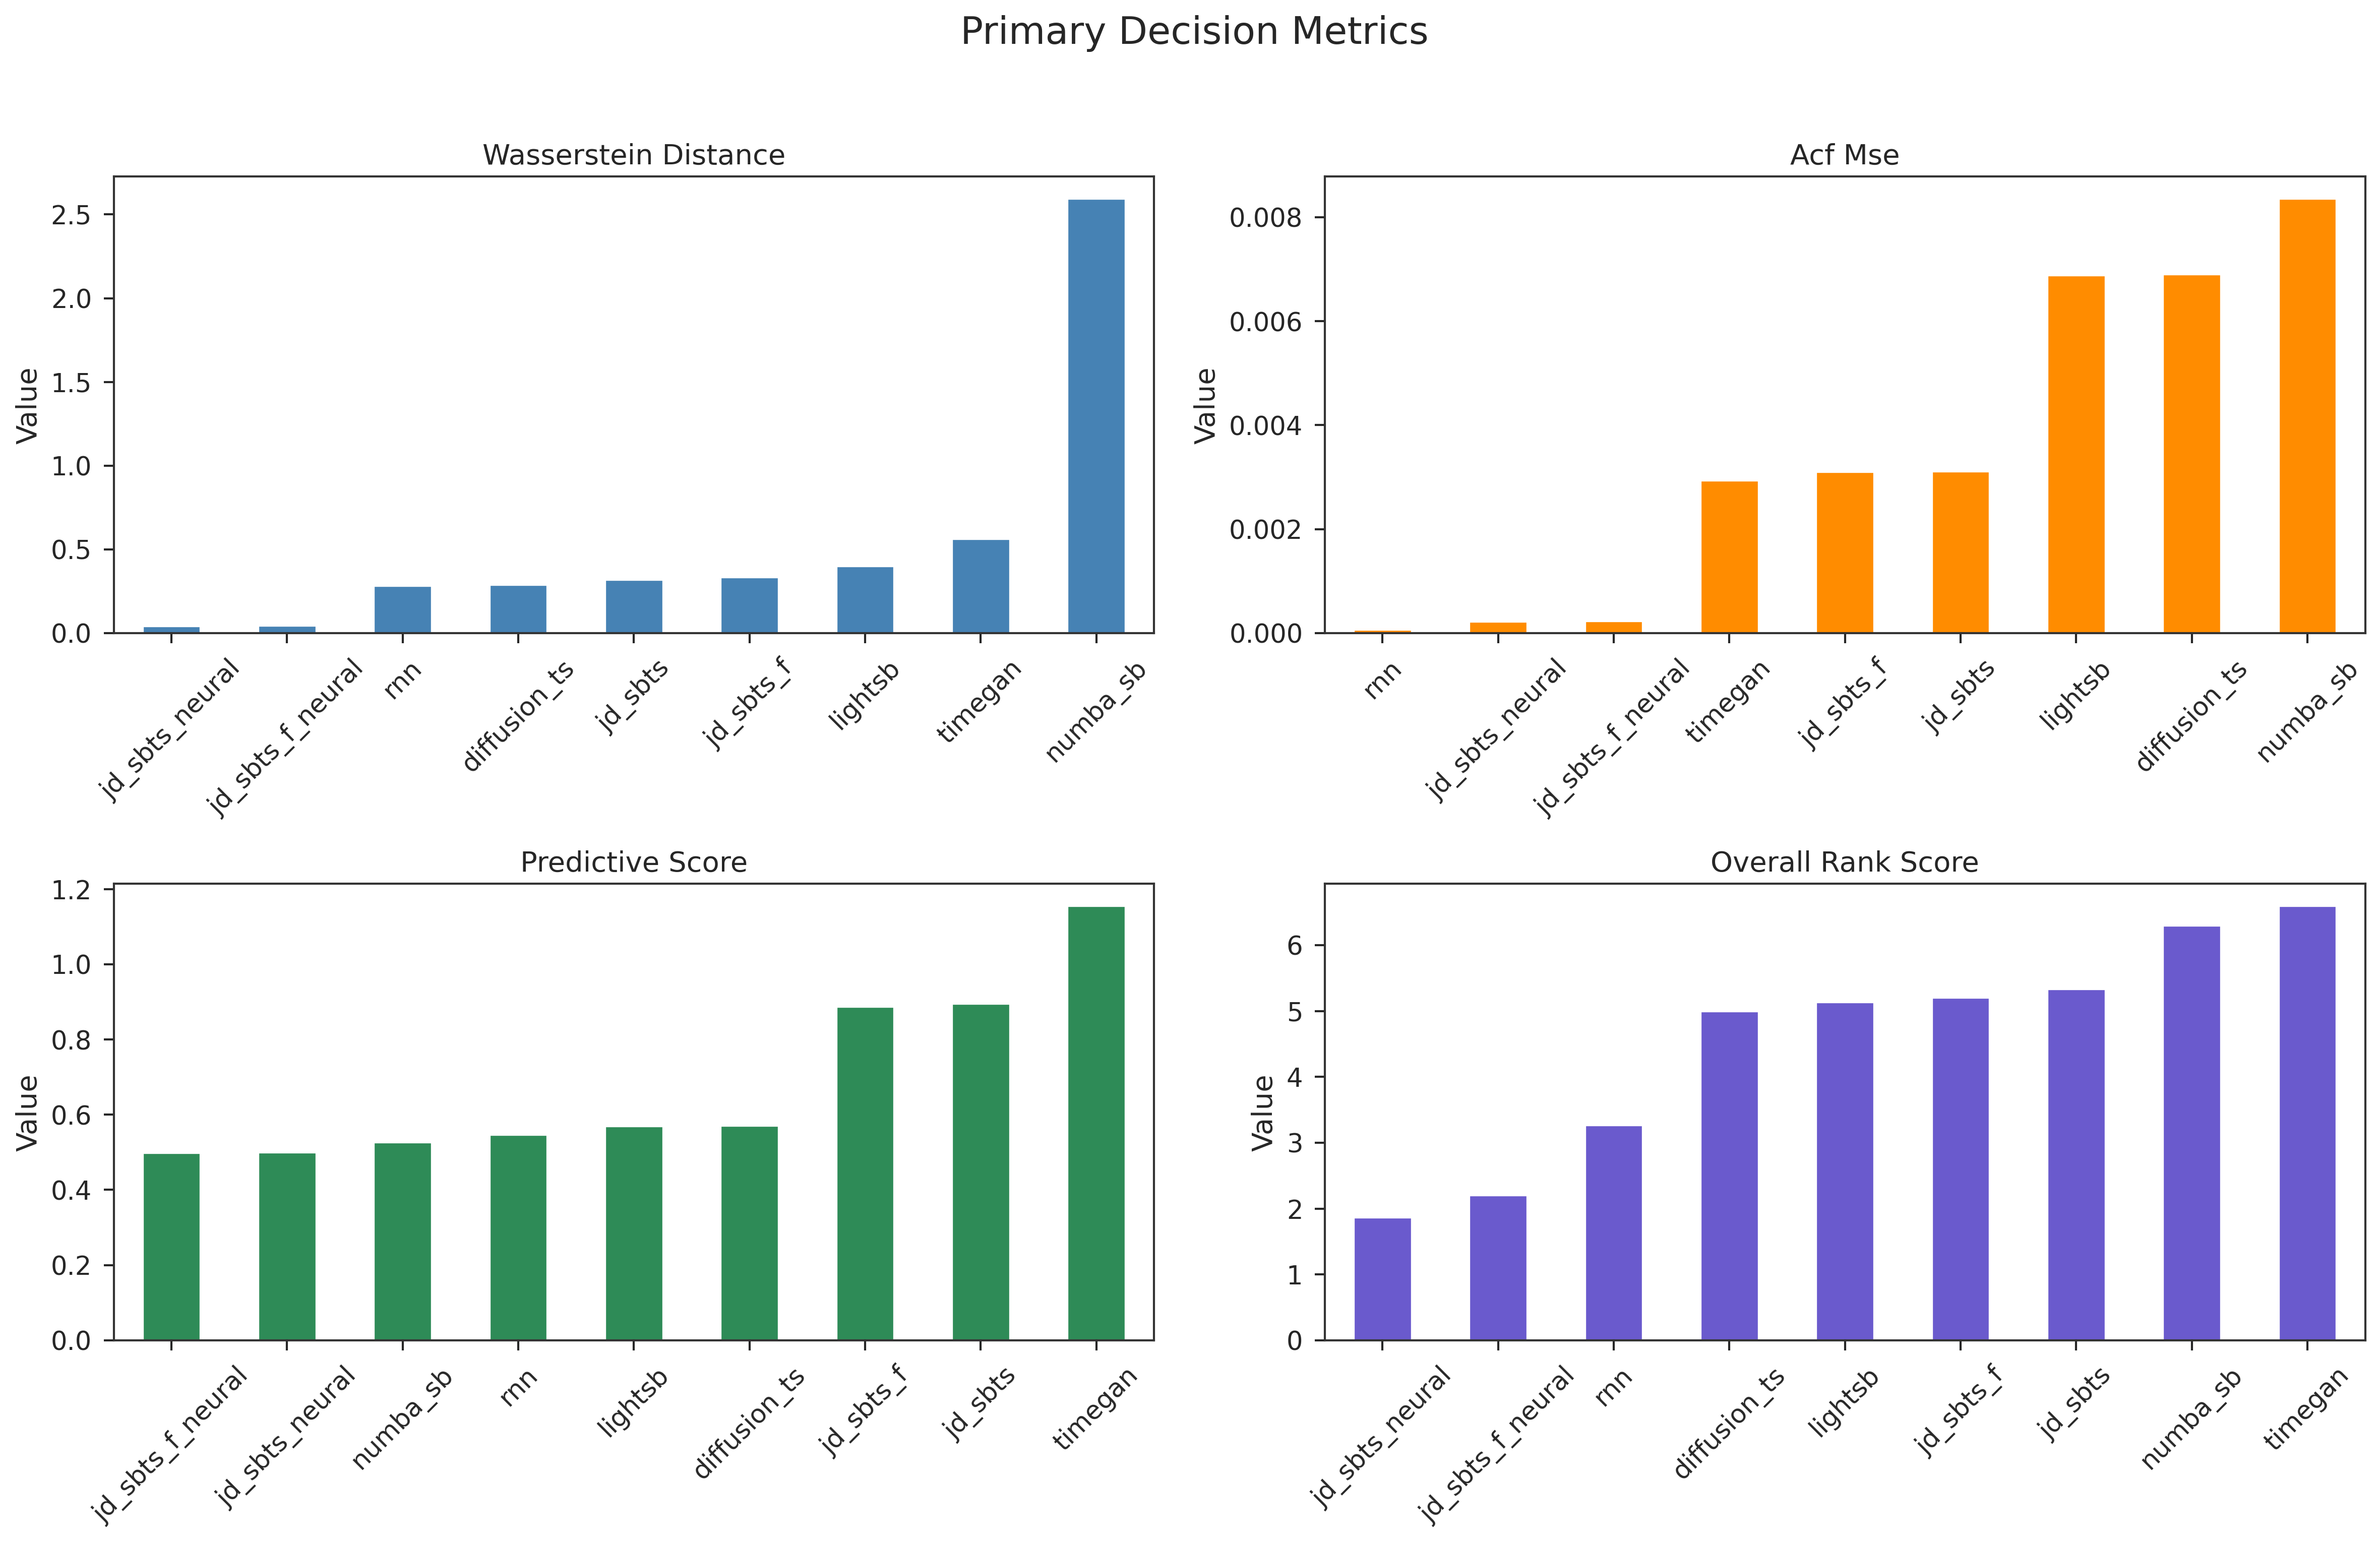

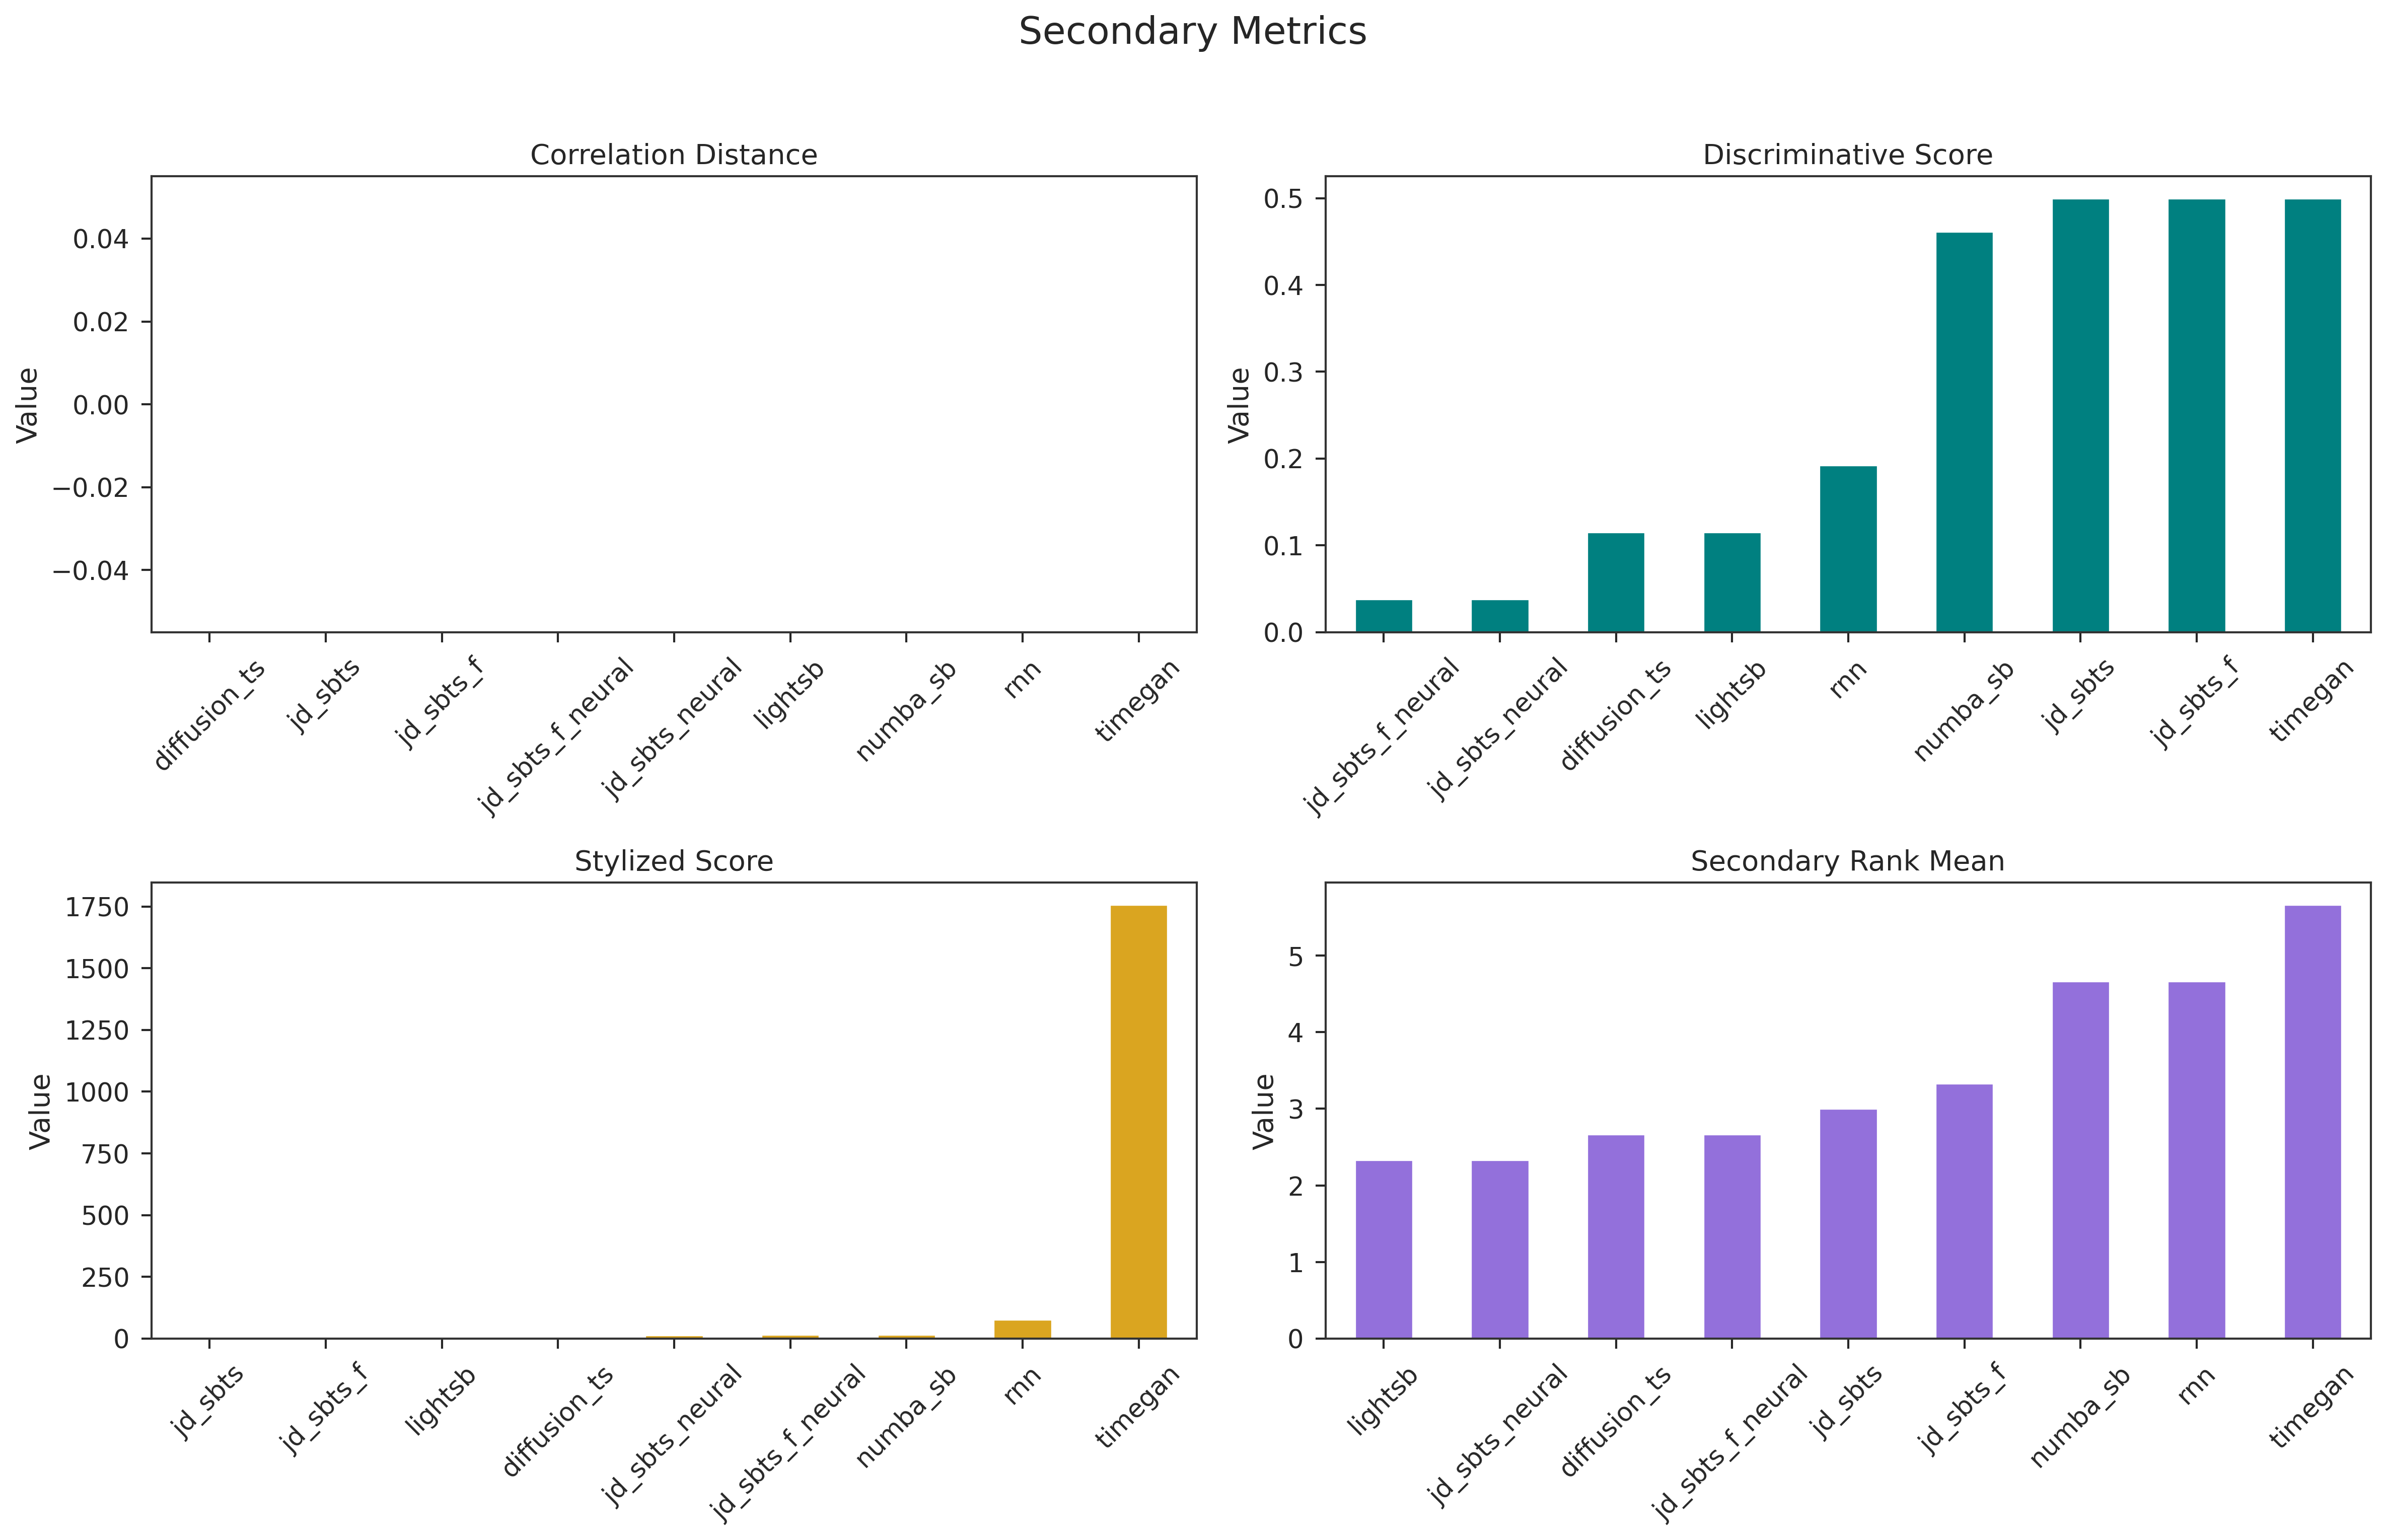

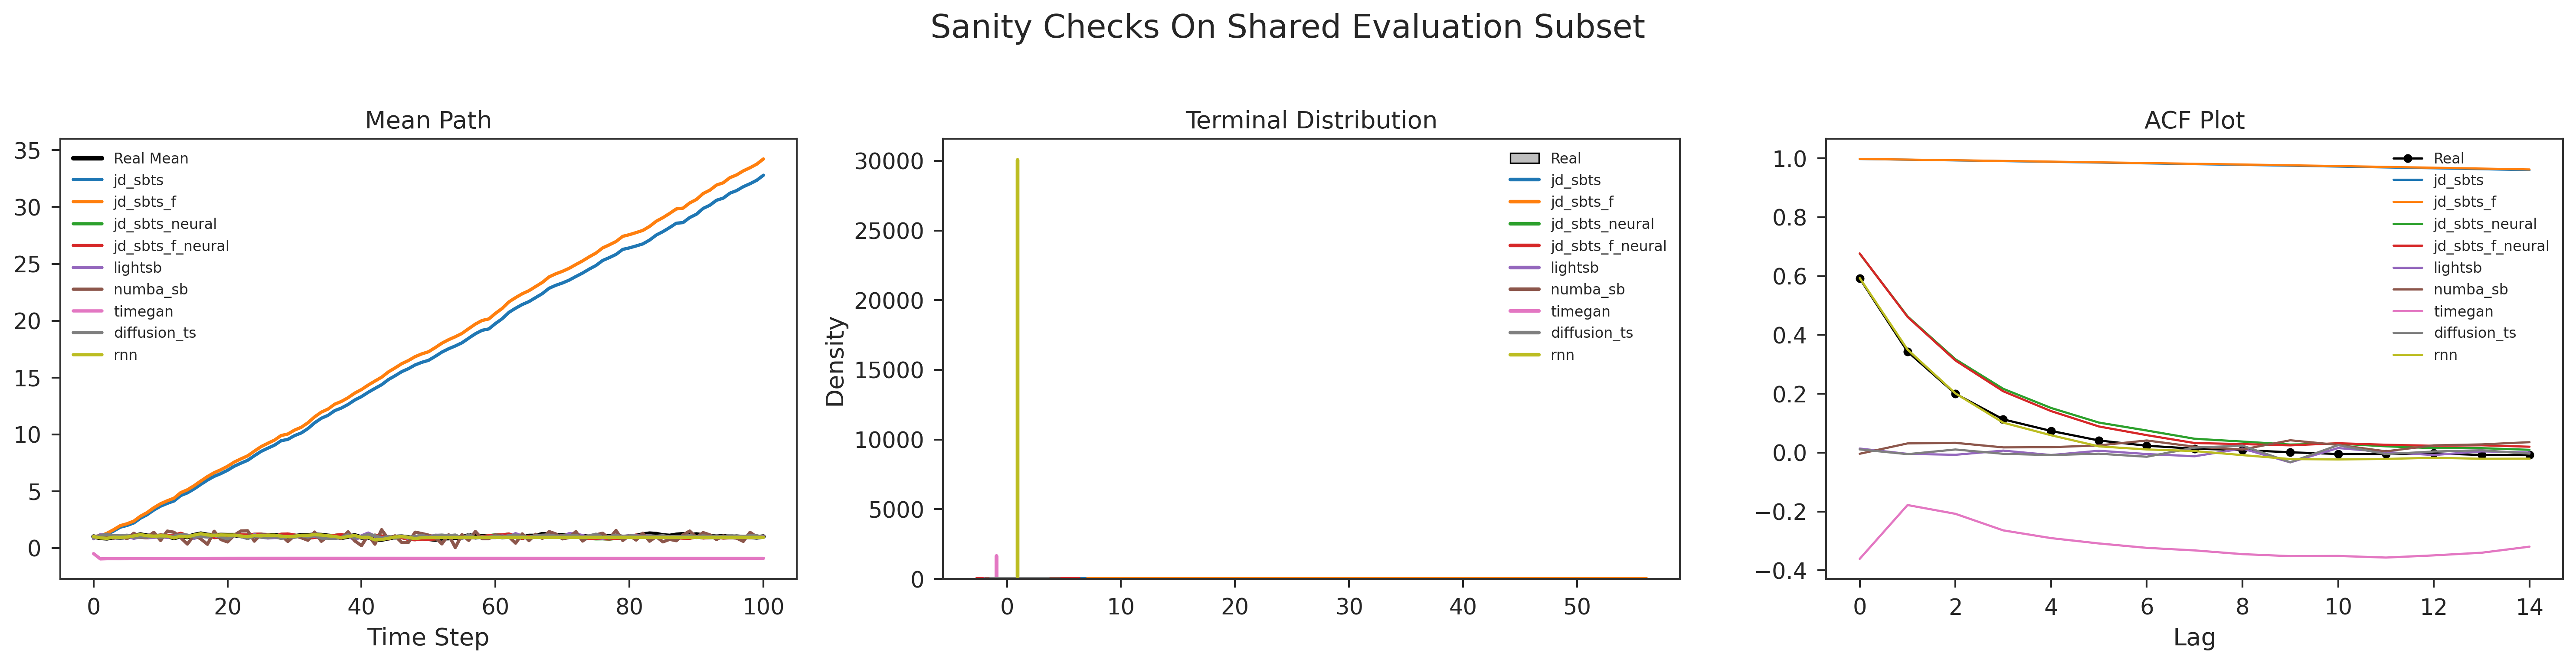

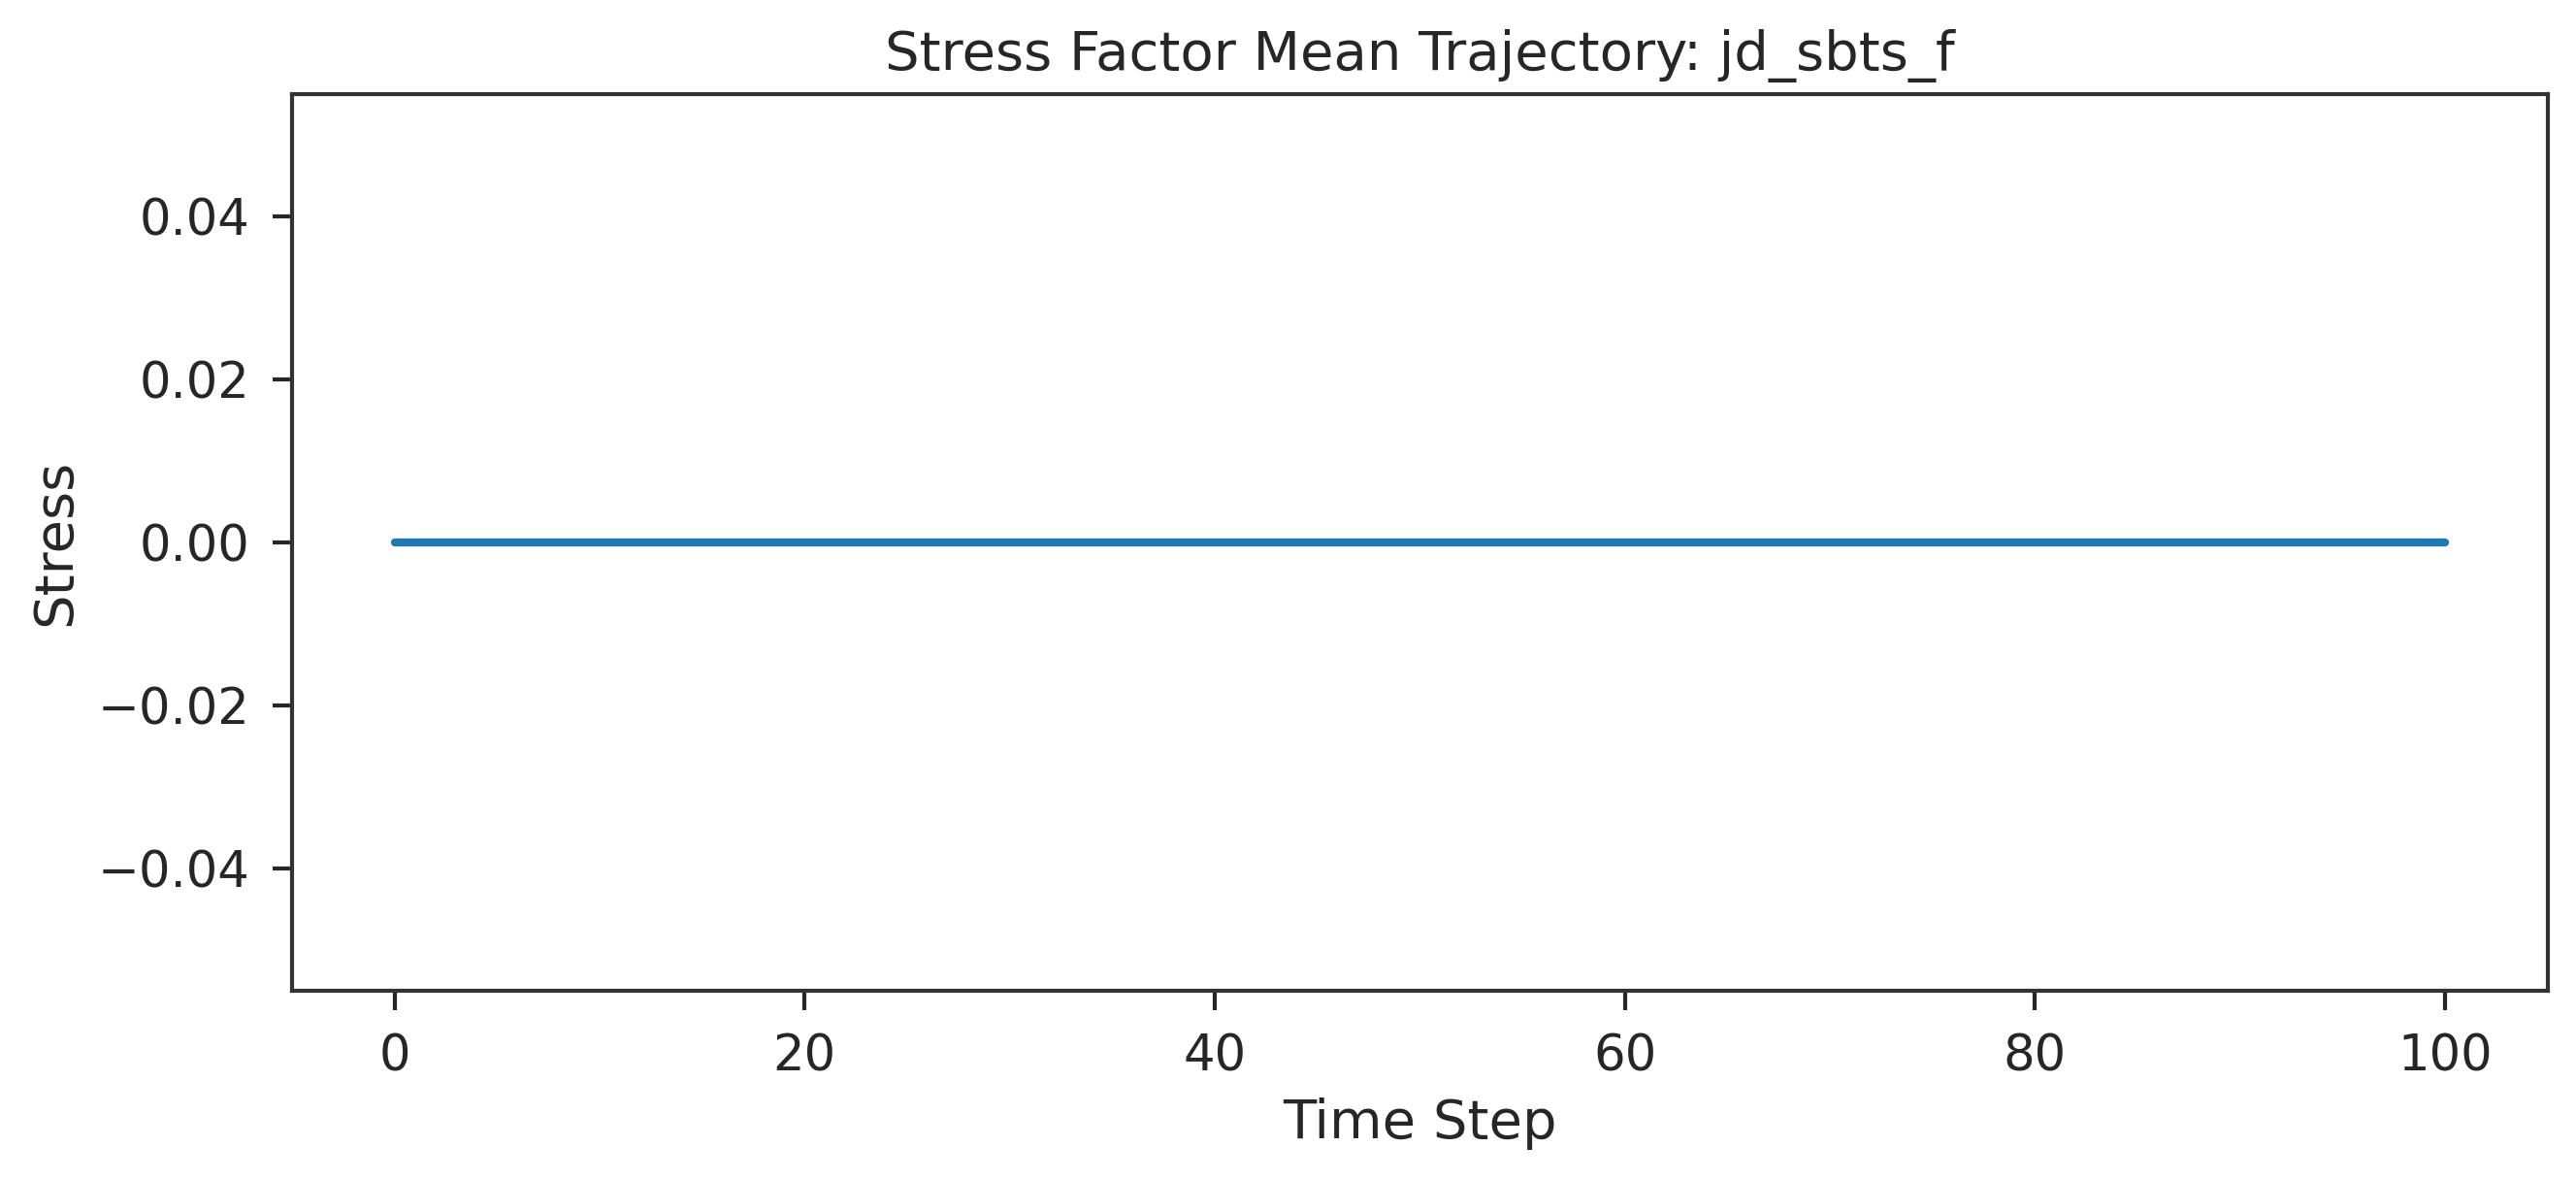

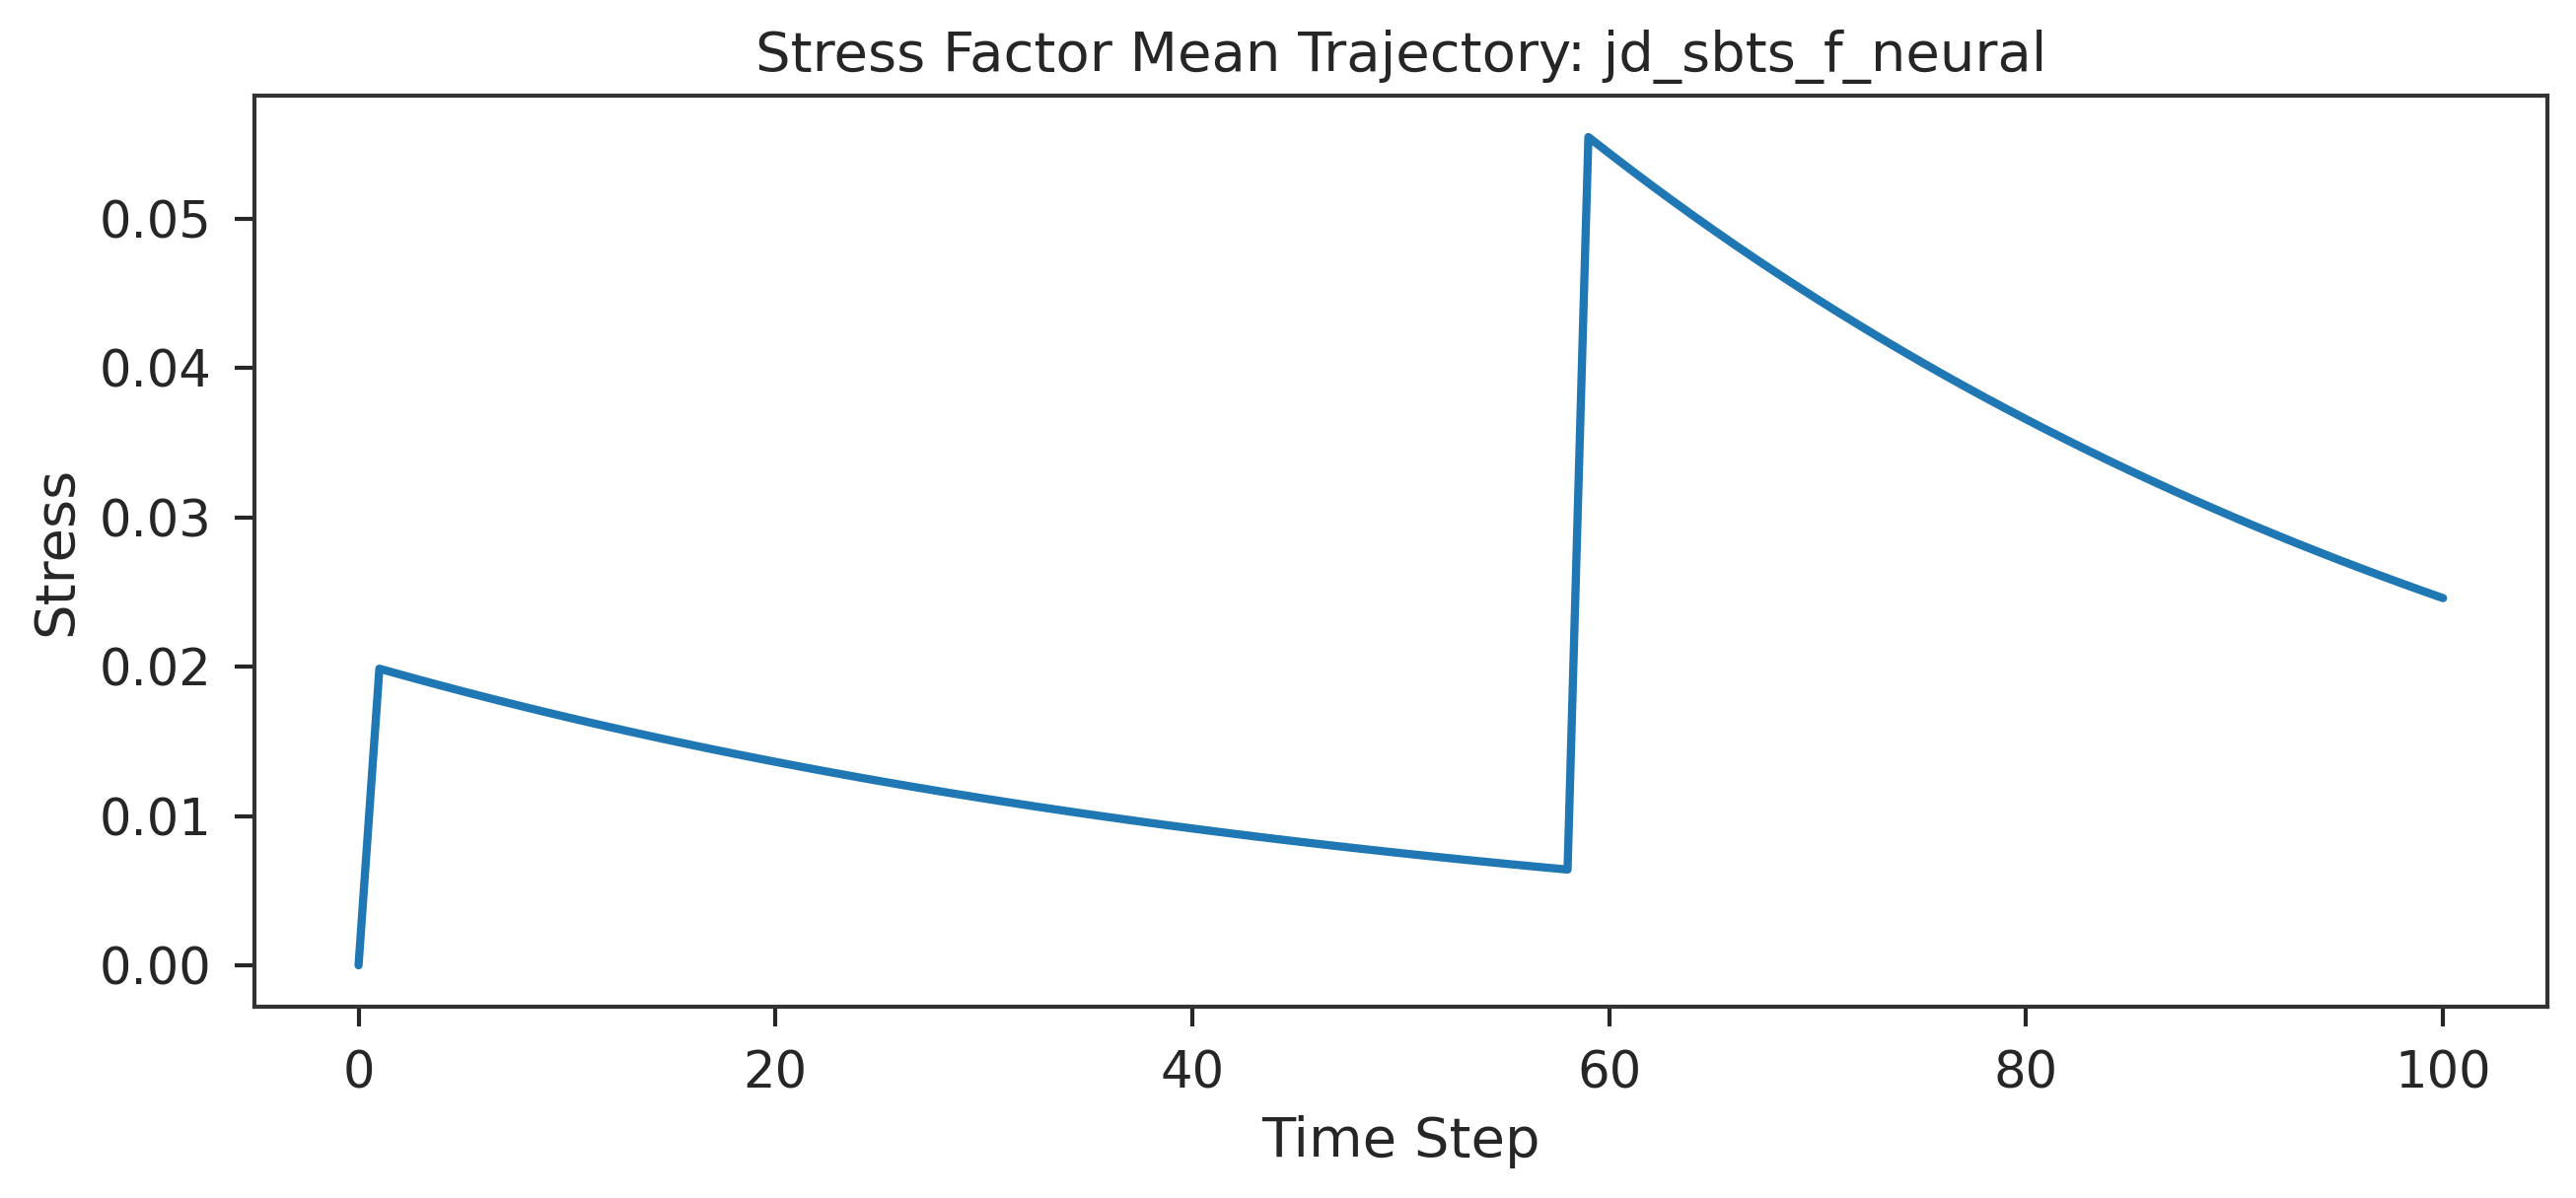

In [16]:
def plot_sorted_metric(ax, frame, column, title, color='steelblue'):
    series = frame[column].dropna().sort_values()
    series.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)


if generated_data:
    methods = list(generated_data.keys())
    sanity_subset = shared_eval_subset.copy()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    main_plot_cols = [col for col in ['wasserstein_distance', 'acf_mse', 'predictive_score'] if col in comparison_df.columns]
    colors = ['steelblue', 'darkorange', 'seagreen']

    for ax, col, color in zip(axes.reshape(-1), main_plot_cols, colors):
        plot_sorted_metric(ax, comparison_df, col, col.replace('_', ' ').title(), color=color)

    ax = axes.reshape(-1)[len(main_plot_cols)]
    plot_sorted_metric(ax, comparison_df, 'overall_rank_score', 'Overall Rank Score', color='slateblue')

    for ax in axes.reshape(-1)[len(main_plot_cols) + 1:]:
        ax.axis('off')

    fig.suptitle('Primary Decision Metrics', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    secondary_plot_cols = [col for col in ['correlation_distance', 'discriminative_score', 'stylized_score'] if col in comparison_df.columns]
    colors = ['firebrick', 'teal', 'goldenrod']

    for ax, col, color in zip(axes.reshape(-1), secondary_plot_cols, colors):
        plot_sorted_metric(ax, comparison_df, col, col.replace('_', ' ').title(), color=color)

    ax = axes.reshape(-1)[len(secondary_plot_cols)]
    plot_sorted_metric(ax, comparison_df, 'secondary_rank_mean', 'Secondary Rank Mean', color='mediumpurple')

    for ax in axes.reshape(-1)[len(secondary_plot_cols) + 1:]:
        ax.axis('off')

    fig.suptitle('Secondary Metrics', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(np.mean(sanity_subset[:, :, 0], axis=0), color='black', linewidth=2.5, label='Real Mean')
    for method in methods:
        gen_subset = generated_data[method][:len(sanity_subset)]
        ax.plot(np.mean(gen_subset[:, :, 0], axis=0), linewidth=1.8, label=method)
    ax.set_title('Mean Path')
    ax.set_xlabel('Time Step')
    ax.legend(fontsize=8)

    ax = axes[1]
    sns.kdeplot(sanity_subset[:, -1, 0], ax=ax, color='black', fill=True, alpha=0.25, label='Real')
    for method in methods:
        gen_subset = generated_data[method][:len(sanity_subset)]
        sns.kdeplot(gen_subset[:, -1, 0], ax=ax, linewidth=2, label=method)
    ax.set_title('Terminal Distribution')
    ax.legend(fontsize=8)

    ax = axes[2]
    max_lag = TRAINING_OVERRIDES['acf_max_lag']
    series = sanity_subset[:, :, 0]
    real_acf = []
    for lag in range(max_lag):
        if lag >= series.shape[1] - 1:
            real_acf.append(0.0)
        else:
            x_t = series[:, :-lag-1].flatten()
            x_k = series[:, lag+1:].flatten()
            real_acf.append(np.corrcoef(x_t, x_k)[0, 1])
    ax.plot(range(max_lag), real_acf, color='black', marker='o', label='Real')

    for method in methods:
        series = generated_data[method][:len(sanity_subset), :, 0]
        acf_vals = []
        for lag in range(max_lag):
            if lag >= series.shape[1] - 1:
                acf_vals.append(0.0)
            else:
                x_t = series[:, :-lag-1].flatten()
                x_k = series[:, lag+1:].flatten()
                acf_vals.append(np.corrcoef(x_t, x_k)[0, 1])
        ax.plot(range(max_lag), acf_vals, marker='x', label=method)
    ax.set_title('ACF Plot')
    ax.set_xlabel('Lag')
    ax.legend(fontsize=8)

    fig.suptitle('Sanity Checks On Shared Evaluation Subset', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

    if stress_trajectories:
        for model_name, stress in stress_trajectories.items():
            plt.figure(figsize=(10, 4))
            plt.plot(np.mean(stress, axis=0), linewidth=2)
            plt.title(f'Stress Factor Mean Trajectory: {model_name}')
            plt.xlabel('Time Step')
            plt.ylabel('Stress')
            plt.show()
